In [ ]:
import pandas as pd
df = pd.read_csv("data.csv")
print(df.head())
print(df.columns)

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_worst  smoothness

#Check the shape

In [ ]:
print(df.shape)

(569, 33)


# check the missing values

In [ ]:
df.drop(columns=['Unnamed: 32', 'id'], inplace=True)
print(df.isna().sum())

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


In [ ]:
#Check class balance
print(df['diagnosis'].value_counts())

diagnosis
B    357
M    212
Name: count, dtype: int64


######The classes are not perfectly equal, so I will use F1-score as the main metric to evaluate the model

#Separate features (X) and label (y)

In [ ]:
from sklearn.model_selection import train_test_split

x=df.drop(columns=["diagnosis"])
y=df["diagnosis"]

#Split into train (80%) and test (20%) sets — use random_state=42


In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded = encoder.transform(y_test)
print(y_train_encoded[:5])

[0 1 0 0 0]


#Model Training

In [ ]:

# 1. Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

log_reg = LogisticRegression(random_state=42)
log_reg.fit(x_train_scaled, y_train)
preds = log_reg.predict(x_test_scaled)

# Random Forest

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier(random_state=42)
rf.fit(x_train, y_train)
preds_rf = rf.predict(x_test)

#KNN

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(x_train_scaled, y_train)
preds_knn = knn.predict(x_test_scaled)


# Model Evaluation

In [ ]:
# Logistic Regression Report
print(classification_report(y_test, preds))

# Random Forest Report
print(classification_report(y_test, preds_rf))

# KNN Report
print(classification_report(y_test, preds_knn))

              precision    recall  f1-score   support

           B       0.97      0.99      0.98        71
           M       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

              precision    recall  f1-score   support

           B       0.96      0.99      0.97        71
           M       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

              precision    recall  f1-score   support

           B       0.96      0.96      0.96        71
           M       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



# Confusion Matrix




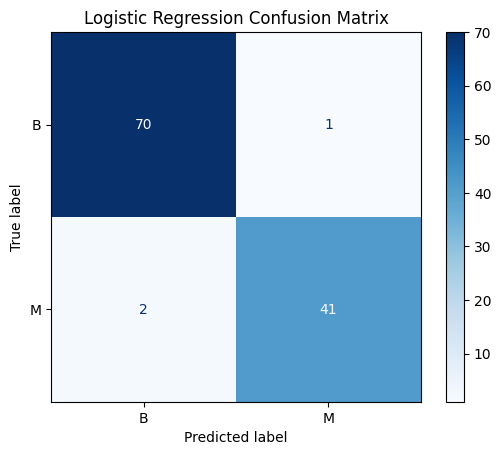

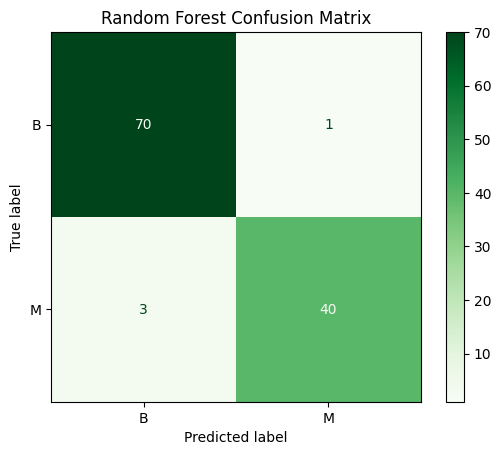

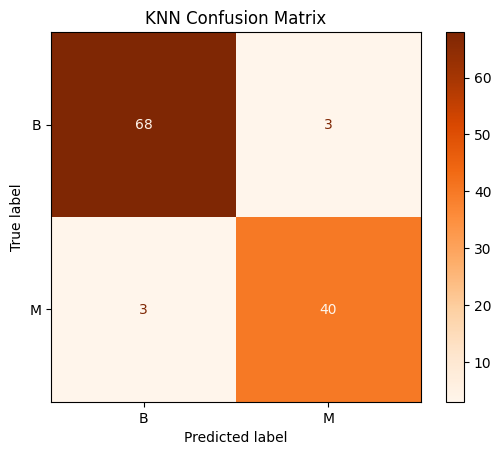

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Logistic Regression Confusion Matrix

ConfusionMatrixDisplay.from_predictions(y_test, preds, cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# Random Forest Confusion Matrix

ConfusionMatrixDisplay.from_predictions(y_test, preds_rf, cmap='Greens')
plt.title("Random Forest Confusion Matrix")
plt.show()

# KNN Confusion Matrix

ConfusionMatrixDisplay.from_predictions(y_test, preds_knn, cmap='Oranges')
plt.title("KNN Confusion Matrix")
plt.show()


#Best Model Selection


In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score,f1_score

results_data = {
'Model': ['Logistic Regression', 'Random Forest', 'KNN'],
'Accuracy': [
accuracy_score(y_test, preds),
accuracy_score(y_test, preds_rf),
accuracy_score(y_test, preds_knn)],
'Precision': [
precision_score(y_test, preds, average='macro'),
precision_score(y_test, preds_rf, average='macro'),
precision_score(y_test, preds_knn, average='macro')],
'Recall': [
recall_score(y_test, preds, average='macro'),
recall_score(y_test, preds_rf, average='macro'),
recall_score(y_test, preds_knn, average='macro')],
'F1-Score': [
f1_score(y_test, preds, average='macro'),
f1_score(y_test, preds_rf, average='macro'),
f1_score(y_test, preds_knn, average='macro')]
}

summary_df = pd.DataFrame(results_data)
summary_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.973684,0.974206,0.969702,0.971863
1,Random Forest,0.964912,0.967257,0.958074,0.962302
2,KNN,0.947368,0.943990,0.943990,0.943990


Selected because it achieved the highest Accuracy 97.37% and F1-score 97.19% among all models.

# Build a neural network

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model_nn = Sequential([
  Input(shape=(x_train_scaled.shape[1],)),
  Dense(32, activation='relu')])

#Dropout

In [ ]:
from tensorflow.keras.layers import Dropout, Dense

model_nn.add(Dropout(0.2))

model_nn.add(Dense(16, activation='relu'))
model_nn.add(Dense(1, activation='sigmoid'))

#Train for at least 10 epochs



In [ ]:

model_nn.compile(
  optimizer='adam',
  loss='binary_crossentropy',
  metrics=['accuracy'])

history = model_nn.fit(
  x_train_scaled,
  y_train_encoded,
  epochs=10,
  batch_size=16,
  validation_split=0.2,
  verbose=1)

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7582 - loss: 0.5575 - val_accuracy: 0.9011 - val_loss: 0.4579
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9093 - loss: 0.3617 - val_accuracy: 0.9121 - val_loss: 0.2946
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9286 - loss: 0.2587 - val_accuracy: 0.9560 - val_loss: 0.2064
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9396 - loss: 0.1859 - val_accuracy: 0.9560 - val_loss: 0.1633
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9533 - loss: 0.1555 - val_accuracy: 0.9451 - val_loss: 0.1395
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9588 - loss: 0.1291 - val_accuracy: 0.9560 - val_loss: 0.1243
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9670 - loss: 0.1296 - val_accuracy: 0.9670 - val_loss: 0.1149
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9588 - loss: 0.1200 - val_accuracy: 0.9670 - val_loss

#Plotting Loss and Accuracy Curves

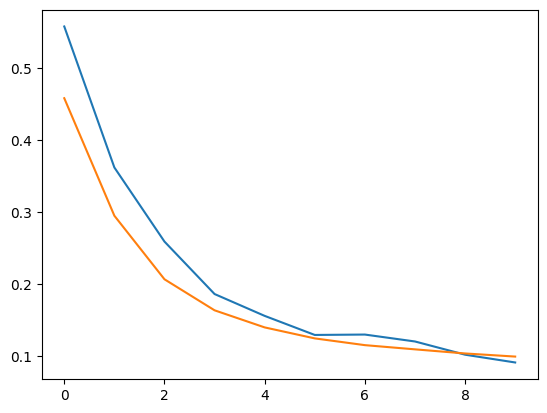

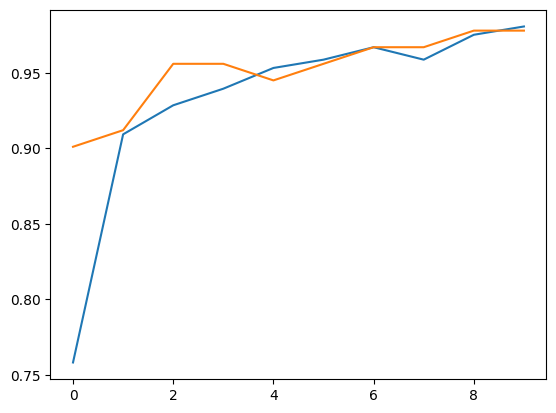

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.show()

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.show()

#Evaluate Neural Network

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

nn_preds = (model_nn.predict(x_test_scaled).flatten() > 0.5).astype(int)
nn_preds_labels = encoder.inverse_transform(nn_preds)

nn_acc = accuracy_score(y_test, nn_preds_labels)
nn_prec = precision_score(y_test, nn_preds_labels, average='macro')
nn_rec = recall_score(y_test, nn_preds_labels, average='macro')
nn_f1 = f1_score(y_test, nn_preds_labels, average='macro')

print(nn_acc, nn_prec, nn_rec, nn_f1)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
0.9824561403508771 0.981329839502129 0.981329839502129 0.981329839502129


In [ ]:
nn_row = {
  'Model': 'Neural Network',
  'Accuracy': nn_acc,
  'Precision': nn_prec,
  'Recall': nn_rec,
  'F1-Score': nn_f1}

summary_df = pd.concat([summary_df, pd.DataFrame([nn_row])], ignore_index=True)
summary_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.973684,0.974206,0.969702,0.971863
1,Random Forest,0.964912,0.967257,0.958074,0.962302
2,KNN,0.947368,0.943990,0.943990,0.943990
3,Neural Network,0.982456,0.981330,0.981330,0.981330


The Neural Network was better than all other models, achieving the highest Accuracy ($98.25\%$) and F1-Score ($98.13\%$). This is because its hidden layers and ReLU activation functions can easily capture complex, non-linear patterns in the dataset.